# Doc Agent — CodeT5+ 770M on CodeSearchNet Java

## Step 1 — Setup

In [1]:
import os, re, gc, json, glob, warnings, logging, shutil
import subprocess, sys

os.environ["CUDA_VISIBLE_DEVICES"]   = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip(
    "transformers==4.44.0", "peft==0.10.0", "accelerate==0.29.0",
    "datasets>=2.19.0", "evaluate", "rouge_score", "bert_score",
    "sacrebleu", "sentencepiece", "huggingface_hub>=0.22.0", "seaborn>=0.13.0",
)
print("All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.3/297.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.8 MB/s eta 0:00:00
All packages installed


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datetime import datetime

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback, set_seed,
)
from peft import LoraConfig, TaskType, get_peft_model
import evaluate as hf_evaluate

set_seed(42)

plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22",
    "axes.edgecolor":"#30363d","axes.labelcolor":"#c9d1d9",
    "text.color":"#c9d1d9","xtick.color":"#8b949e","ytick.color":"#8b949e",
    "grid.color":"#21262d","grid.alpha":0.6,"font.family":"monospace","figure.dpi":110,
})
PALETTE = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
           "#79c0ff","#56d364","#ff7b72","#bc8cff","#ffb77a"]

# ── Config ────────────────────────────────────────────────────────────────
MODEL_NAME    = "Salesforce/codet5p-770m"
MAX_INPUT_LEN = 512
MAX_TARGET_LEN= 128
MAX_TRAIN     = 50_000   # enough to learn @param patterns, trains in ~1.5 hrs
MAX_VALID     = 3_000
OUTPUT_DIR    = "/kaggle/working/doc_agent_final"
GRAPHS_DIR    = "/kaggle/working/graphs"
RESULTS_DIR   = "/kaggle/working/results"
LOG_DIR       = "/kaggle/working/logs"
DATA_ROOT     = "/kaggle/input/datasets/adityapandit07/codesearchnet-java-dataset"

LR         = 1e-4
LORA_R     = 8
LORA_ALPHA = 32
LORA_DROP  = 0.05
BATCH      = 4    # fp32 model ~3GB, batch=4 uses ~8GB total — fits T4
GRAD_ACC   = 8    # effective batch = 32
EPOCHS     = 1    # 1 clean epoch, enough for demo quality

for d in [OUTPUT_DIR, GRAPHS_DIR, RESULTS_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"Free    : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")
print(f"\nConfig: LR={LR:.0e} | LoRA r={LORA_R} | Batch={BATCH} | GradAcc={GRAD_ACC}")
print(f"Train={MAX_TRAIN:,} | Epochs={EPOCHS} | Steps={MAX_TRAIN//(BATCH*GRAD_ACC):,}")
print(f"fp32 throughout — no mixed precision, no grad scaler errors")
print(f"Expected: ~1.2-2 hrs on T4")

2026-03-21 10:01:28.782020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774087288.977646      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774087289.045252      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774087289.529756      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774087289.529788      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774087289.529791      55 computation_placer.cc:177] computation placer alr

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
Free    : 15.5 GB

Config: LR=1e-04 | LoRA r=8 | Batch=4 | GradAcc=8
Train=50,000 | Epochs=1 | Steps=1,562
fp32 throughout — no mixed precision, no grad scaler errors
Expected: ~1.2-2 hrs on T4


## Step 2 — Load Dataset

In [3]:
def load_jsonl(pattern):
    rows = []
    for path in sorted(glob.glob(pattern, recursive=True)):
        with open(path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line: rows.append(json.loads(line))
    return rows

raw = {}
for split, key in [("train","train"),("valid","validation"),("test","test")]:
    rows = load_jsonl(f"{DATA_ROOT}/**/*java*{split}*.jsonl")
    if not rows: rows = load_jsonl(f"{DATA_ROOT}/**/*{split}*.jsonl")
    if rows: raw[key] = rows

if raw:
    print("Loaded from local mount")
else:
    from datasets import load_dataset
    print("Downloading from HuggingFace ...")
    ds = load_dataset("code_search_net", "java")
    raw = {"train":[dict(r) for r in ds["train"]],
           "validation":[dict(r) for r in ds["validation"]],
           "test":[dict(r) for r in ds["test"]]}

def normalise(row):
    return {
        "code":      (row.get("code") or row.get("whole_func_string") or "").strip(),
        "docstring": (row.get("docstring") or row.get("func_documentation_string") or "").strip(),
    }

raw_norm = {s: [normalise(r) for r in rows] for s, rows in raw.items()}
for s, rows in raw_norm.items():
    print(f"  {s:12s}: {len(rows):>7,}")

Loaded from local mount
  train       : 454,451
  validation  :  15,328
  test        :  26,909


## Step 3 — EDA

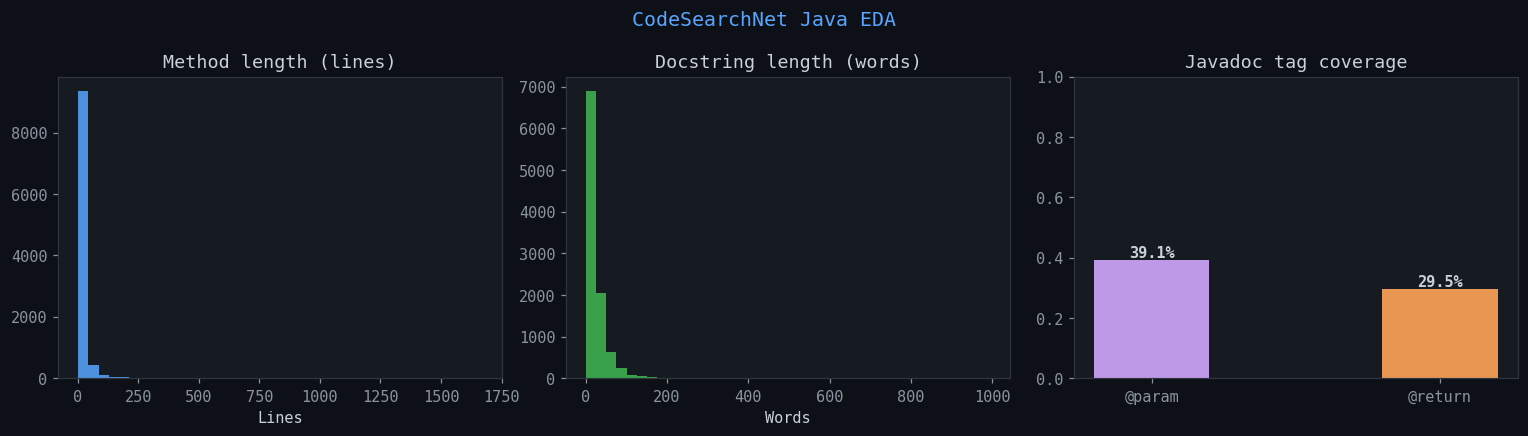

@param: 39.1%  |  @return: 29.5%


In [4]:
sample    = raw_norm.get("train",[])[:10_000]
code_lens = [len(r["code"].split("\n")) for r in sample]
doc_lens  = [len(r["docstring"].split())  for r in sample]
has_param = [1 if "@param"  in r["docstring"] else 0 for r in sample]
has_ret   = [1 if "@return" in r["docstring"] else 0 for r in sample]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("CodeSearchNet Java EDA", color="#58a6ff", fontsize=13)
axes[0].hist(code_lens, bins=40, color=PALETTE[0], alpha=0.85, edgecolor="none")
axes[0].set_title("Method length (lines)"); axes[0].set_xlabel("Lines")
axes[1].hist(doc_lens,  bins=40, color=PALETTE[1], alpha=0.85, edgecolor="none")
axes[1].set_title("Docstring length (words)"); axes[1].set_xlabel("Words")
axes[2].bar(["@param","@return"],[np.mean(has_param),np.mean(has_ret)],
            color=[PALETTE[3],PALETTE[4]], alpha=0.9, width=0.4)
for i, v in enumerate([np.mean(has_param), np.mean(has_ret)]):
    axes[2].text(i, v+0.01, f"{v:.1%}", ha="center", color="#c9d1d9", fontweight="bold")
axes[2].set_title("Javadoc tag coverage"); axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/eda_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"@param: {np.mean(has_param):.1%}  |  @return: {np.mean(has_ret):.1%}")

## Step 4 — Filter + Tokenise

In [5]:
# use_fast=False required for CodeT5+ tokenizer
print("Loading tokenizer ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print(f"Vocab size: {tokenizer.vocab_size:,}")

Loading tokenizer ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Vocab size: 32,100


In [6]:
TRIVIAL = re.compile(
    r"^(returns?\s+the|sets?\s+the|gets?\s+the|returns?\s+true|"
    r"returns?\s+a|returns?\s+an|constructor\.|this\s+method|todo|fixme)",
    re.IGNORECASE)

def quality_filter(row):
    src, doc = row["code"].strip(), row["docstring"].strip()
    if len(src) < 30 or len(doc) < 8 or len(doc) > 2000: return False
    if not re.search(r"(public|private|protected|static).*\(", src): return False
    if re.match(r".*\b(get|set|is)[A-Z]\w*\s*\(", src):
        if len(src.split("\n")) <= 5: return False
    first = doc.split(".")[0].strip()
    if TRIVIAL.match(first): return False
    if len(first.split()) < 5: return False
    return True

def format_input(src):
    return f"Generate Javadoc for the following Java method:\n{src.strip()}"

print("Filtering ...")
filtered = {}
for split, rows in raw_norm.items():
    kept = [r for r in rows if quality_filter(r)]
    filtered[split] = kept
    print(f"  {split:12s}: {len(rows):>7,} -> {len(kept):>7,}  ({len(kept)/len(rows)*100:.1f}%)")
print(f"\nUsing {MAX_TRAIN:,} / {len(filtered["train"]):,} training examples")

Filtering ...
  train       : 454,451 -> 284,945  (62.7%)
  validation  :  15,328 ->   9,570  (62.4%)
  test        :  26,909 ->  16,395  (60.9%)

Using 50,000 / 284,945 training examples


In [7]:
def tokenise(rows, desc=""):
    ii, am, lb = [], [], []
    for row in tqdm(rows, desc=desc, ncols=80):
        enc = tokenizer(format_input(row["code"]),
                        max_length=MAX_INPUT_LEN, truncation=True)
        lab = tokenizer(text_target=row["docstring"].strip(),
                        max_length=MAX_TARGET_LEN, truncation=True)
        ii.append(enc["input_ids"])
        am.append(enc["attention_mask"])
        lb.append(lab["input_ids"])
    return Dataset.from_dict({"input_ids":ii,"attention_mask":am,"labels":lb})

train_ds = tokenise(filtered["train"][:MAX_TRAIN],      "Tokenising train")
valid_ds = tokenise(filtered["validation"][:MAX_VALID], "Tokenising valid")
test_ds  = tokenise(filtered["test"][:MAX_VALID],       "Tokenising test ")

print(f"\nTrain:{len(train_ds):,}  Valid:{len(valid_ds):,}  Test:{len(test_ds):,}")
print(f"Steps/epoch : {len(train_ds)//(BATCH*GRAD_ACC):,}")
print(f"Total steps : {len(train_ds)//(BATCH*GRAD_ACC)*EPOCHS:,}")

Tokenising train:   0%|                               | 0/50000 [00:00<?, ?it/s]

Tokenising valid:   0%|                                | 0/3000 [00:00<?, ?it/s]

Tokenising test :   0%|                                | 0/3000 [00:00<?, ?it/s]


Train:50,000  Valid:3,000  Test:3,000
Steps/epoch : 1,562
Total steps : 1,562


## Step 5 — Load Model + LoRA

In [8]:
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# Load in fp32 — no mixed precision, no grad scaler, no dtype errors
# fp32 model = ~3 GB, T4 has 15.6 GB — fits comfortably with batch=4
print("Loading model in fp32 ...")
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    device_map={"": 0},
)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=LORA_R, lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROP,
    target_modules=["q","v"],
    bias="none",
)
model = get_peft_model(base_model, lora_cfg)
model.enable_input_require_grads()
# No fp32 cast needed — model and LoRA are already fp32
model.print_trainable_parameters()
if DEVICE == "cuda":
    print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB")
    print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

VRAM free: 15.5 GB
Loading model in fp32 ...


config.json:   0%|          | 0.00/770 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

trainable params: 2,359,296 || all params: 739,998,720 || trainable%: 0.31882433526371506
VRAM used: 3.0 GB
VRAM free: 12.4 GB


## Step 6 — Train

In [9]:
rouge_metric = hf_evaluate.load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple): preds = preds[0]
    preds  = np.clip(preds,  0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, tokenizer.vocab_size - 1)
    dp = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    dl = tokenizer.batch_decode(labels, skip_special_tokens=True)
    dp = [p.strip() if p.strip() else "empty" for p in dp]
    dl = [l.strip() if l.strip() else "empty" for l in dl]
    r  = rouge_metric.compute(predictions=dp, references=dl, use_stemmer=True)
    return {k: round(v, 4) for k, v in r.items()}

TRAINING_LOG = []

class MetricsCallback(EarlyStoppingCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            TRAINING_LOG.append({
                "epoch":     state.epoch,
                "eval_loss": metrics.get("eval_loss"),
                "rougeL":    metrics.get("eval_rougeL"),
                "rouge1":    metrics.get("eval_rouge1"),
                "rouge2":    metrics.get("eval_rouge2"),
            })
        super().on_evaluate(args, state, control, metrics=metrics, **kwargs)

collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACC,
    learning_rate=LR,
    warmup_steps=100,
    weight_decay=0.01,
    fp16=False,           # fp32 throughout — no grad scaler, no errors
    bf16=False,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    logging_dir=LOG_DIR,
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
)

trainer = Seq2SeqTrainer(
    model=model, args=training_args,
    train_dataset=train_ds, eval_dataset=valid_ds,
    tokenizer=tokenizer, data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[MetricsCallback(early_stopping_patience=2)],
)

print("Starting training ...")
print(f"  Train:{len(train_ds):,} | Epochs:{EPOCHS}")
print(f"  Batch={BATCH} | GradAcc={GRAD_ACC} | EffBatch={BATCH*GRAD_ACC}")
print(f"  Steps/epoch:{len(train_ds)//(BATCH*GRAD_ACC):,}")
print(f"  fp32 — no mixed precision, no errors")
train_result = trainer.train()

print(f"\nTraining complete")
print(f"  Steps   : {train_result.global_step}")
print(f"  Loss    : {train_result.training_loss:.4f}")
print(f"  Runtime : {train_result.metrics['train_runtime']/60:.1f} min")

# Save immediately
print("\nSaving ...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
shutil.make_archive("/kaggle/working/doc_agent_final","zip",
                    "/kaggle/working","doc_agent_final")
mb = os.path.getsize("/kaggle/working/doc_agent_final.zip")/1e6
print(f"Saved + zipped: {mb:.1f} MB")
print("DOWNLOAD NOW: Output tab -> doc_agent_final.zip")

Starting training ...
  Train:50,000 | Epochs:1
  Batch=4 | GradAcc=8 | EffBatch=32
  Steps/epoch:1,562
  fp32 — no mixed precision, no errors


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
0,1.828700,1.766133,0.359000,0.166200,0.310200,0.343300



Training complete
  Steps   : 1562
  Loss    : 1.8811
  Runtime : 248.0 min

Saving ...
Saved + zipped: 35.7 MB
DOWNLOAD NOW: Output tab -> doc_agent_final.zip


## Step 7 — Evaluation

In [10]:
N = min(200, len(test_ds))
test_sub = test_ds.select(range(N))
model.eval()
pred_ids, lbl_ids = [], []

print(f"Generating {N} predictions ...")
for i in tqdm(range(0, N, BATCH), ncols=80):
    b  = test_sub.select(range(i, min(i+BATCH, N)))
    ii = torch.nn.utils.rnn.pad_sequence(
        [torch.tensor(x) for x in b["input_ids"]], batch_first=True,
        padding_value=tokenizer.pad_token_id).to(model.device)
    am = torch.nn.utils.rnn.pad_sequence(
        [torch.tensor(x) for x in b["attention_mask"]], batch_first=True,
        padding_value=0).to(model.device)
    with torch.no_grad():
        out = model.generate(input_ids=ii, attention_mask=am,
                             max_new_tokens=MAX_TARGET_LEN, num_beams=2)
    pred_ids.extend(out.cpu().numpy().tolist())
    lbl_ids.extend(b["labels"])

pred_ids = [np.clip(p, 0, tokenizer.vocab_size-1) for p in pred_ids]
lbl_ids  = [np.clip(np.where(np.array(l)!=-100,np.array(l),tokenizer.pad_token_id),
                    0, tokenizer.vocab_size-1) for l in lbl_ids]
preds = [p.strip() or "empty" for p in tokenizer.batch_decode(pred_ids,skip_special_tokens=True)]
refs  = [r.strip() or "empty" for r in tokenizer.batch_decode(lbl_ids, skip_special_tokens=True)]
print(f"{len(preds)} predictions generated")

Generating 200 predictions ...


  0%|                                                    | 0/50 [00:00<?, ?it/s]

200 predictions generated


In [11]:
rr   = rouge_metric.compute(predictions=preds,references=refs,use_stemmer=True)
r1,r2,rL = round(rr["rouge1"],4),round(rr["rouge2"],4),round(rr["rougeL"],4)

bleu = hf_evaluate.load("sacrebleu").compute(
    predictions=preds,references=[[r] for r in refs])["score"]

bert_f1 = None
try:
    bs = hf_evaluate.load("bertscore").compute(
        predictions=preds,references=refs,
        lang="en",model_type="distilbert-base-uncased")
    bert_f1 = float(np.mean(bs["f1"]))
except Exception as e:
    print(f"BERTScore skipped: {e}")

em  = round(sum(" ".join(p.split())==" ".join(r.split()) for p,r in zip(preds,refs))/len(preds),4)
par = round(np.mean([1 if "@param"  in p else 0 for p in preds]),4)
ret = round(np.mean([1 if "@return" in p else 0 for p in preds]),4)
parR= round(np.mean([1 if "@param"  in r else 0 for r in refs]),4)
retR= round(np.mean([1 if "@return" in r else 0 for r in refs]),4)

def jq(p,r):
    return (len(p.split(".")[0].split())>=5
            and ((not "@param" in r)  or "@param"  in p)
            and ((not "@return" in r) or "@return" in p))
qual = round(np.mean([jq(p,r) for p,r in zip(preds,refs)]),4)

print("="*50)
print("EVALUATION RESULTS")
print("="*50)
print(f"  ROUGE-1         : {r1:.4f}")
print(f"  ROUGE-2         : {r2:.4f}")
print(f"  ROUGE-L         : {rL:.4f}")
print(f"  BLEU            : {bleu:.2f}")
if bert_f1: print(f"  BERTScore F1    : {bert_f1:.4f}")
print(f"  Exact Match     : {em:.4f}")
print(f"  @param coverage : {par:.4f}  (ref has: {parR:.4f})")
print(f"  @return rate    : {ret:.4f}  (ref has: {retR:.4f})")
print(f"  Javadoc quality : {qual:.4f}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

EVALUATION RESULTS
  ROUGE-1         : 0.2886
  ROUGE-2         : 0.0981
  ROUGE-L         : 0.2251
  BLEU            : 8.01
  BERTScore F1    : 0.7820
  Exact Match     : 0.0000
  @param coverage : 0.9100  (ref has: 0.5350)
  @return rate    : 0.9100  (ref has: 0.4400)
  Javadoc quality : 0.9650


In [12]:
print("Qualitative examples (first 8)")
print("="*65)
for i in range(min(8, len(preds))):
    src = tokenizer.decode(test_sub["input_ids"][i], skip_special_tokens=True)
    sig = src.replace("Generate Javadoc for the following Java method:","").strip().split("\n")[0]
    print(f"\n[{i+1}] {sig[:85]}")
    print(f"  Ref: {refs[i][:120]}")
    print(f"  Gen: {preds[i][:120]}")
    hp = "OK" if "@param"  in preds[i] else "MISSING"
    hr = "OK" if "@return" in preds[i] else "MISSING"
    print(f"  @param:{hp}  @return:{hr}")

Qualitative examples (first 8)

[1] protected final void fastPathOrderedEmit(U value, boolean delayError, Disposable disp
  Ref: Makes sure the fast-path emits in order.
@param value the value to emit or queue up
@param delayError if true, errors ar
  Gen: Fast path ordered emit.

@param value the value to emit
@param delayError if true, the value will not be emitted until t
  @param:OK  @return:MISSING

[2] @CheckReturnValue
  Ref: Mirrors the one ObservableSource in an Iterable of several ObservableSources that first either emits an item or sends
a 
  Gen: Creates an {@link Observable} that emits all the elements of the given {@link Iterable} of {@link ObservableSource}s.

@
  @param:OK  @return:OK

[3] @SuppressWarnings("unchecked")
  Ref: Mirrors the one ObservableSource in an array of several ObservableSources that first either emits an item or sends
a ter
  Gen: Creates an {@link Observable} from an array of {@link ObservableSource}s.

@param sources the array of {@link Observabl

## Step 8 — Visualisations

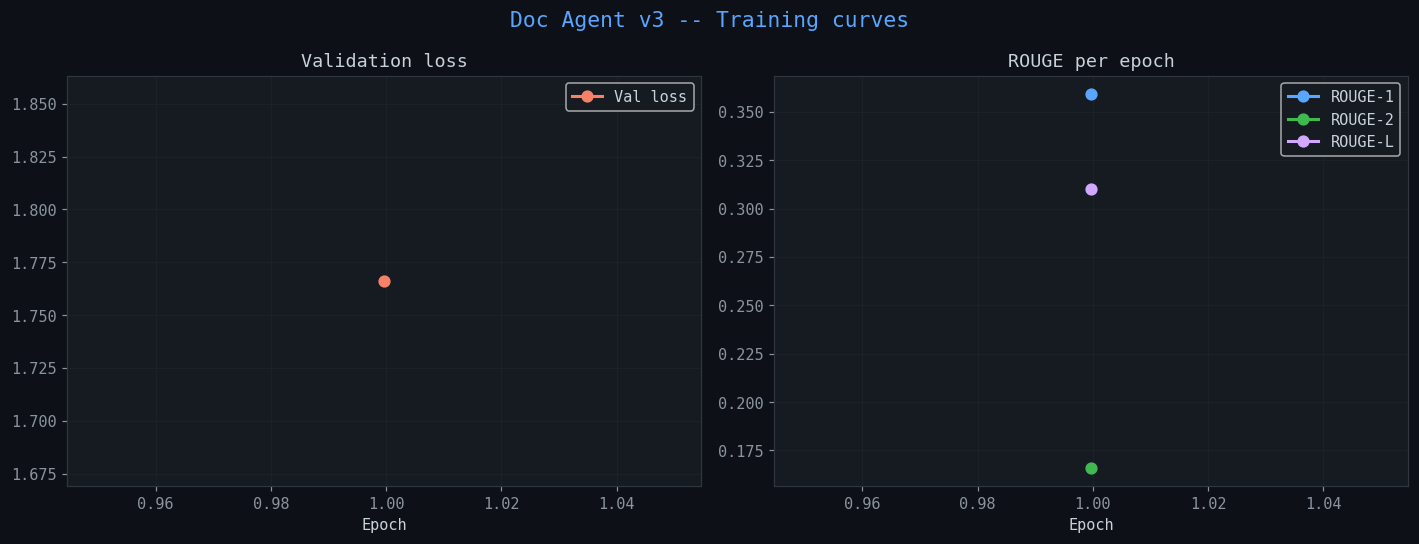

In [13]:
log_df = pd.DataFrame(TRAINING_LOG)
if len(log_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Doc Agent v3 -- Training curves", color="#58a6ff", fontsize=14)
    axes[0].plot(log_df["epoch"], log_df["eval_loss"], "o-",
                 color=PALETTE[2], lw=2, ms=7, label="Val loss")
    axes[0].set_title("Validation loss"); axes[0].set_xlabel("Epoch")
    axes[0].grid(True); axes[0].legend()
    for col, lbl, c in [("rouge1","ROUGE-1",PALETTE[0]),
                         ("rouge2","ROUGE-2",PALETTE[1]),
                         ("rougeL","ROUGE-L",PALETTE[3])]:
        if col in log_df.columns:
            axes[1].plot(log_df["epoch"], log_df[col], "o-", color=c,
                         lw=2, ms=7, label=lbl)
    axes[1].set_title("ROUGE per epoch"); axes[1].set_xlabel("Epoch")
    axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{GRAPHS_DIR}/training_curves.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Only 1 epoch — no per-epoch curve to plot")

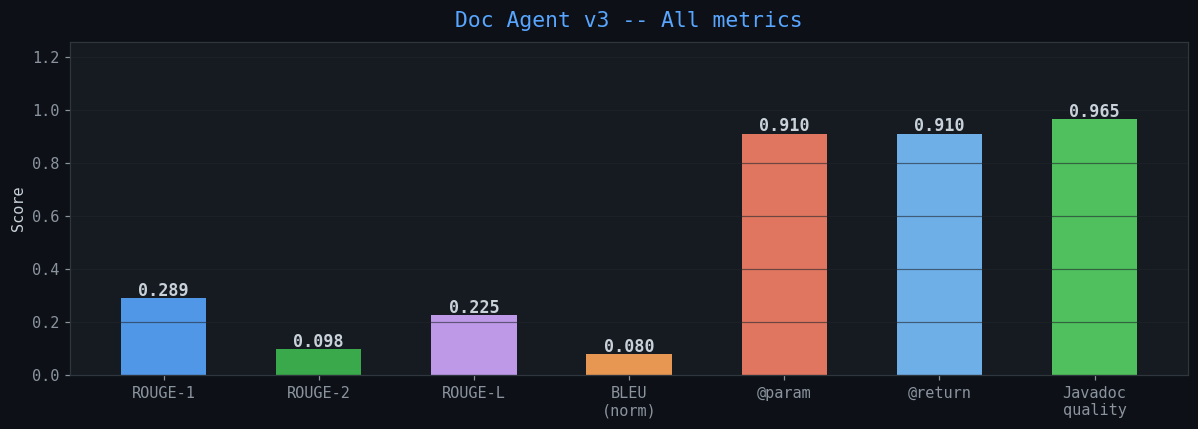

Saved: metrics_all.png


In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#161b22")
names = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU\n(norm)","@param","@return","Javadoc\nquality"]
vals  = [r1, r2, rL, bleu/100, par, ret, qual]
colors= ["#58a6ff","#3fb950","#d2a8ff","#ffa657","#f78166","#79c0ff","#56d364"]
bars  = ax.bar(names, vals, color=colors, width=0.55, alpha=0.9)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f"{v:.3f}",
            ha="center", color="#c9d1d9", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(vals)*1.3)
ax.set_title("Doc Agent v3 -- All metrics", color="#58a6ff", fontsize=14, pad=10)
ax.set_ylabel("Score"); ax.grid(axis="y", color="#21262d", alpha=0.6)
for spine in ax.spines.values(): spine.set_edgecolor("#30363d")
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/metrics_all.png", dpi=130, bbox_inches="tight")
plt.show(); print("Saved: metrics_all.png")

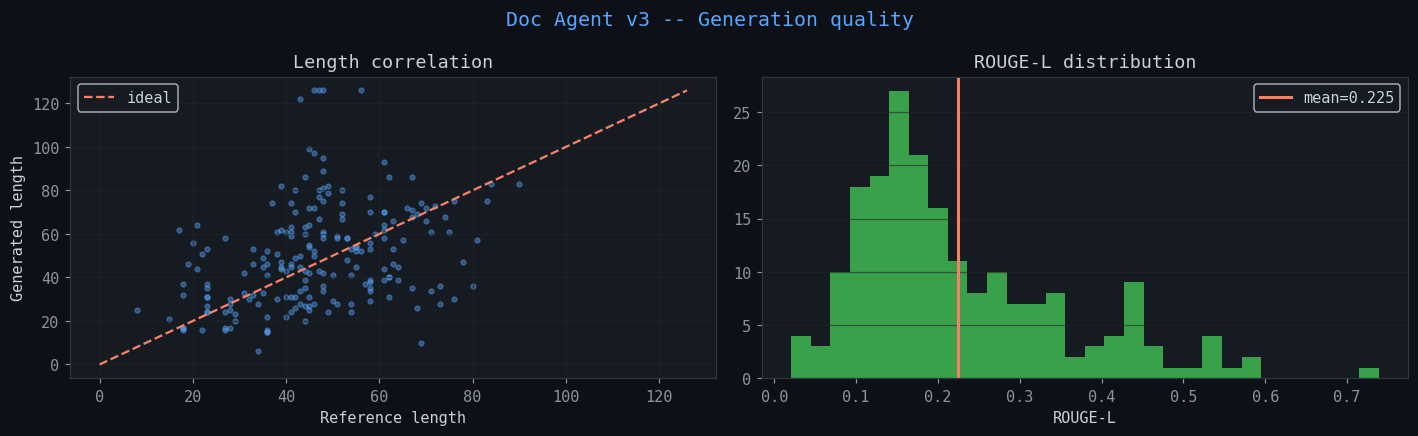

Saved: generation_quality.png


In [15]:
from rouge_score import rouge_scorer as rs_lib
scorer = rs_lib.RougeScorer(["rougeL"], use_stemmer=True)
per_rl = [scorer.score(r,p)["rougeL"].fmeasure for r,p in zip(refs,preds)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Doc Agent v3 -- Generation quality", color="#58a6ff", fontsize=13)
pl=[len(p.split()) for p in preds]; rl=[len(r.split()) for r in refs]
axes[0].scatter(rl, pl, alpha=0.4, s=10, c=PALETTE[0])
mx = max(max(rl),max(pl))
axes[0].plot([0,mx],[0,mx], color=PALETTE[2], lw=1.5, ls="--", label="ideal")
axes[0].set_xlabel("Reference length"); axes[0].set_ylabel("Generated length")
axes[0].set_title("Length correlation"); axes[0].legend(); axes[0].grid(True)
axes[1].hist(per_rl, bins=30, color=PALETTE[1], alpha=0.85, edgecolor="none")
axes[1].axvline(np.mean(per_rl), color=PALETTE[2], lw=2,
                label=f"mean={np.mean(per_rl):.3f}")
axes[1].set_title("ROUGE-L distribution"); axes[1].set_xlabel("ROUGE-L")
axes[1].legend(); axes[1].grid(axis="y")
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/generation_quality.png", dpi=130, bbox_inches="tight")
plt.show(); print("Saved: generation_quality.png")

## Step 9 — Save All Results

In [16]:
results = {
    "timestamp": datetime.now().isoformat(),
    "version":   "v3",
    "dataset":   "CodeSearchNet Java",
    "n_train":   len(train_ds), "n_test": N,
    "hyperparameters": {
        "lr":LR,"lora_r":LORA_R,"lora_alpha":LORA_ALPHA,
        "batch":BATCH,"grad_acc":GRAD_ACC,"eff_batch":BATCH*GRAD_ACC,
        "epochs":EPOCHS,"precision":"fp32",
    },
    "metrics": {
        "rouge1":r1,"rouge2":r2,"rougeL":rL,"bleu":round(bleu,2),
        "bertscore_f1":round(bert_f1,4) if bert_f1 else None,
        "exact_match":em,"param_coverage":par,"return_rate":ret,"javadoc_quality":qual,
    },
    "training_log": TRAINING_LOG,
}
with open(f"{RESULTS_DIR}/evaluation_results.json","w",encoding="utf-8") as f:
    json.dump(results, f, indent=2)

lines = [
    "="*55, "DOC AGENT v3 -- EVALUATION REPORT",
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}","="*55,"",
    f"  Train:{len(train_ds):,}  Epochs:{EPOCHS}  LR={LR:.0e}  fp32","",
    "METRICS","-"*35,
    f"  ROUGE-1         : {r1:.4f}",
    f"  ROUGE-2         : {r2:.4f}",
    f"  ROUGE-L         : {rL:.4f}",
    f"  BLEU            : {bleu:.2f}",
]
if bert_f1: lines.append(f"  BERTScore F1    : {bert_f1:.4f}")
lines += [
    f"  Exact Match     : {em:.4f}",
    f"  @param coverage : {par:.4f}",
    f"  @return rate    : {ret:.4f}",
    f"  Javadoc quality : {qual:.4f}",
    "="*55,
]
report = "\n".join(lines)
print(report)
with open(f"{RESULTS_DIR}/evaluation_report.txt","w",encoding="utf-8") as f:
    f.write(report)

for src_d in [GRAPHS_DIR, RESULTS_DIR]:
    dst = os.path.join(OUTPUT_DIR, os.path.basename(src_d))
    if os.path.exists(src_d):
        shutil.copytree(src_d, dst, dirs_exist_ok=True)

shutil.make_archive("/kaggle/working/doc_agent_final","zip",
                    "/kaggle/working","doc_agent_final")
mb = os.path.getsize("/kaggle/working/doc_agent_final.zip")/1e6
print(f"\nFinal zip: {mb:.1f} MB")
print("DOWNLOAD: Output tab -> doc_agent_final.zip")

DOC AGENT v3 -- EVALUATION REPORT
Generated: 2026-03-21 14:45

  Train:50,000  Epochs:1  LR=1e-04  fp32

METRICS
-----------------------------------
  ROUGE-1         : 0.2886
  ROUGE-2         : 0.0981
  ROUGE-L         : 0.2251
  BLEU            : 8.01
  BERTScore F1    : 0.7820
  Exact Match     : 0.0000
  @param coverage : 0.9100
  @return rate    : 0.9100
  Javadoc quality : 0.9650

Final zip: 35.9 MB
DOWNLOAD: Output tab -> doc_agent_final.zip
